In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/DV/AAPL.csv")

In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10409 entries, 0 to 10408
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10409 non-null  object 
 1   Open       10409 non-null  float64
 2   High       10409 non-null  float64
 3   Low        10409 non-null  float64
 4   Close      10409 non-null  float64
 5   Adj Close  10409 non-null  float64
 6   Volume     10409 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 569.4+ KB


In [ ]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df = df.sort_values('Date')

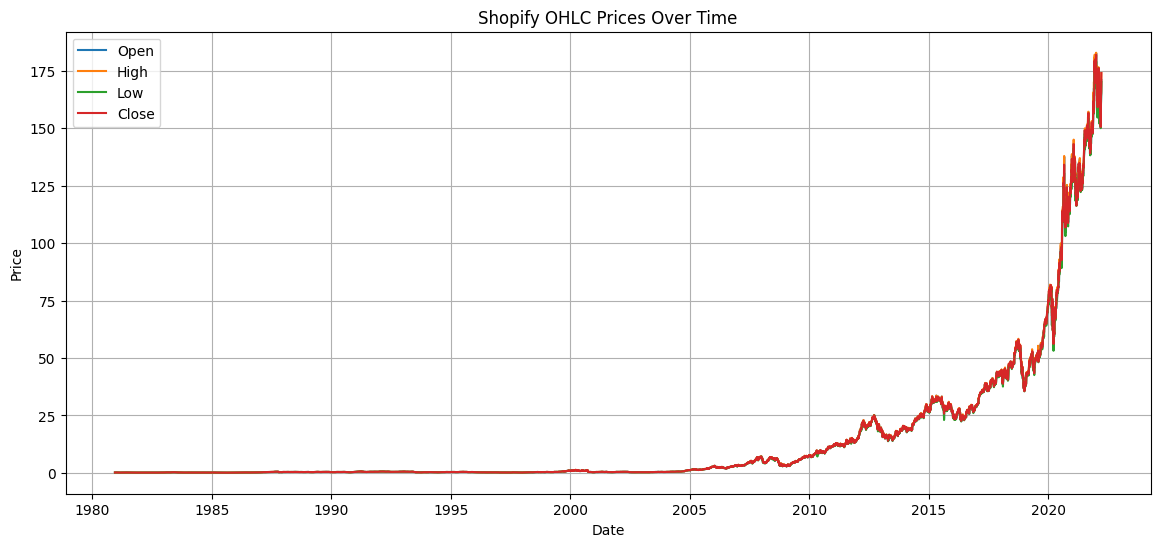

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Low'], label='Low')
plt.plot(df['Date'], df['Close'], label='Close')

plt.title('Shopify OHLC Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

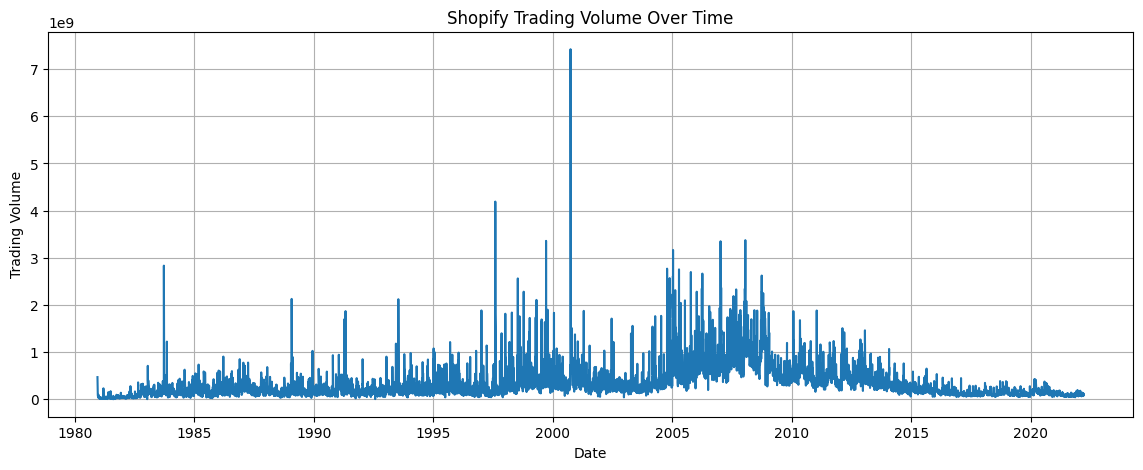

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df['Date'], df['Volume'])

plt.title('Shopify Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.grid(True)
plt.show()

In [ ]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

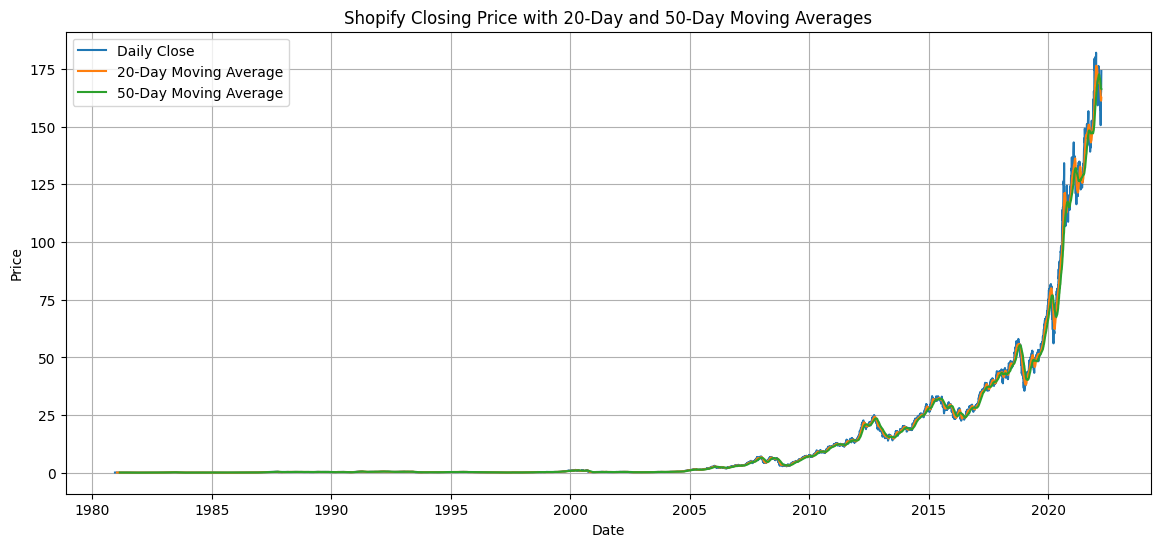

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], label='Daily Close')
plt.plot(df['Date'], df['MA20'], label='20-Day Moving Average')
plt.plot(df['Date'], df['MA50'], label='50-Day Moving Average')

plt.title('Shopify Closing Price with 20-Day and 50-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df['Daily_Return'] = df['Close'].pct_change()

In [ ]:
df[['Date', 'Close', 'Daily_Return']].head()

,Date,Close,Daily_Return
0,1980-12-12,0.128348,NaN
1,1980-12-15,0.121652,-0.052171
2,1980-12-16,0.112723,-0.073398
3,1980-12-17,0.115513,0.024751
4,1980-12-18,0.118862,0.028992


In [ ]:
returns = df['Daily_Return'].dropna()

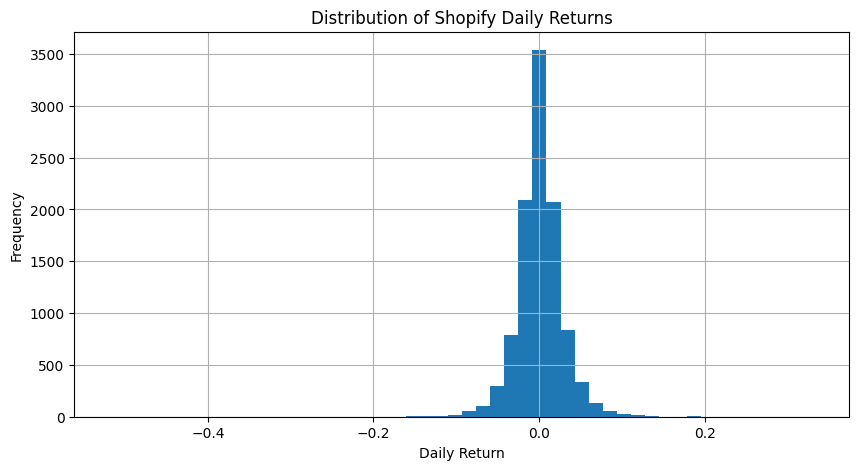

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(returns, bins=50)

plt.title('Distribution of Shopify Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

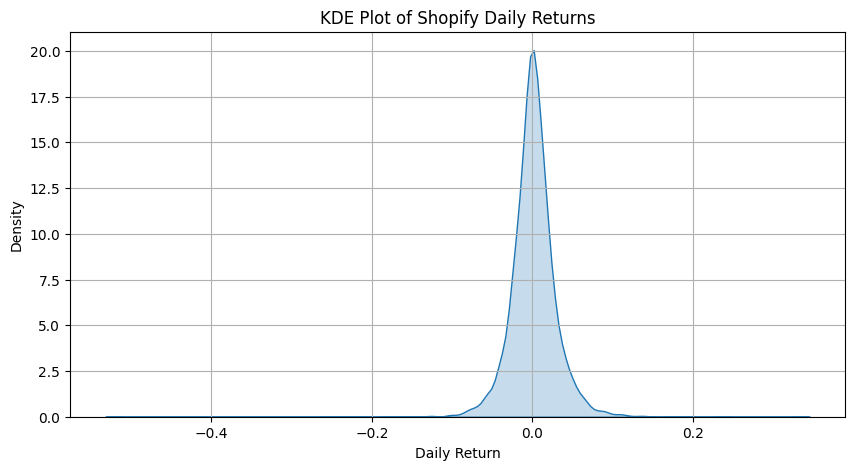

In [ ]:
plt.figure(figsize=(10,5))

sns.kdeplot(returns, fill=True)

plt.title('KDE Plot of Shopify Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [ ]:
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=20).std()

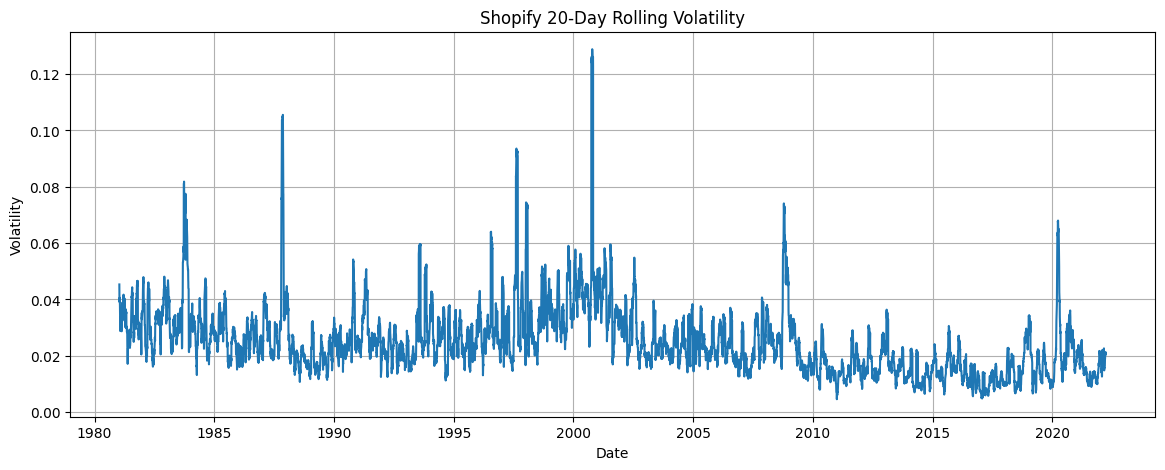

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df['Date'], df['Rolling_Volatility'])

plt.title('Shopify 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

In [ ]:
print("Mean Return:", returns.mean())
print("Median Return:", returns.median())
print("Standard Deviation:", returns.std())
print("Minimum Return:", returns.min())
print("Maximum Return:", returns.max())

Mean Return: 0.0011025843242663373
Median Return: 0.0
Standard Deviation: 0.028367848373307095
Minimum Return: -0.5186919654118827
Maximum Return: 0.3322804371126069


In [ ]:
print("25th Percentile:", returns.quantile(0.25))
print("75th Percentile:", returns.quantile(0.75))

25th Percentile: -0.013078353305623208
75th Percentile: 0.014710809250685408


In [ ]:
print(returns.describe())

count    10408.000000
mean         0.001103
std          0.028368
min         -0.518692
25%         -0.013078
50%          0.000000
75%          0.014711
max          0.332280
Name: Daily_Return, dtype: float64


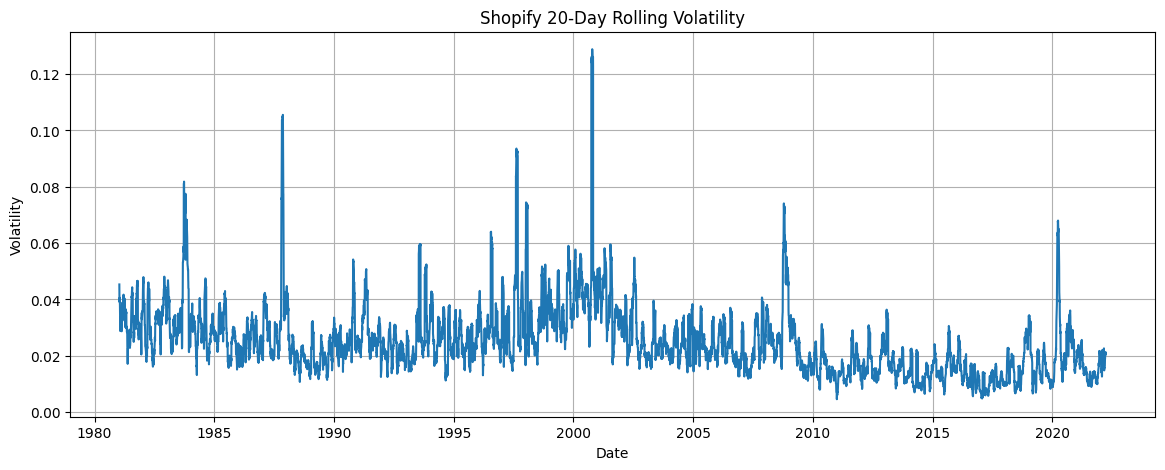

In [ ]:
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=20).std()

plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Rolling_Volatility'])

plt.title('Shopify 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

In [ ]:
top_volatility = df.loc[
    df['Daily_Return'].abs().nlargest(10).index,
    ['Date', 'Close', 'Daily_Return']
]

print(top_volatility.sort_values('Date'))

           Date     Close  Daily_Return
703  1983-09-23  0.108259     -0.253844
1731 1987-10-19  0.325893     -0.243524
1736 1987-10-26  0.250000     -0.211267
3183 1993-07-16  0.245536     -0.230767
3247 1993-10-15  0.252232      0.189471
3943 1996-07-18  0.186384      0.237035
4209 1997-08-06  0.234933      0.332280
4312 1998-01-02  0.145089      0.238088
4314 1998-01-06  0.169085      0.192915
5004 2000-09-29  0.459821     -0.518692
